# Feature Importance Analysis (SHAP)

**Purpose**: Identify which specific gaze/pupil/behavior features drive predictions in the decision window (-2 to 0 seconds before submit).

**Method**: SHAP (SHapley Additive exPlanations) values for Random Forest models

**Deliverable**: Top features with SHAP importance scores across different modalities

**Parameterized**: Set `TIMEFRAME` to run PRE or POST analysis.

In [1]:
# ============================================================================
# CONFIGURATION: Set timeframe for analysis
# ============================================================================
TIMEFRAME = 'PRE'  # Options: 'PRE', 'POST'
# ============================================================================

print(f"\n{'='*70}")
print(f"FEATURE IMPORTANCE ANALYSIS (SHAP): {TIMEFRAME}-DECISION PERIOD")
print(f"{'='*70}\n")


FEATURE IMPORTANCE ANALYSIS (SHAP): PRE-DECISION PERIOD



In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
import shap

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## Load Features

Load the extracted features for the specified timeframe (PRE or POST decision period).

In [3]:
# Load features
with open(f'../../data/features/extracted_features_{TIMEFRAME}.pkl', 'rb') as f:
    feature_data = pickle.load(f)

data = feature_data['merged_df']

# Load EEG features and inner-join on trial_id
with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)

eeg_features_df = eeg_data['eeg_features_df']
eeg_cols = eeg_data['feature_columns']

data = data.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

print(f"Total trials (after EEG merge): {len(data)}")
print(f"Subjects: {data['subject_id'].nunique()}")
print(f"Outcome distribution: {data['outcome'].value_counts().to_dict()}")
print(f"EEG features: {len(eeg_cols)}")

Total trials (after EEG merge): 9365
Subjects: 80
Outcome distribution: {1: 6157, 0: 3208}
EEG features: 16


## Prepare Data

We'll analyze four modalities separately:
1. **Physiology (Pupil)**: 13 features
2. **Gaze**: 20 features
3. **Behavior**: task variables
4. **EEG**: 16 band × region features (Delta/Theta/Alpha/Beta × Frontal/Central/Parietal/Occipital)

Plus combined models: Physiology + Gaze, and All features together.

In [4]:
# Define feature groups (with _pre suffix)
physiology_features = [
    'pupil_mean_pre', 'pupil_std_pre', 'pupil_slope_pre', 'time_to_peak_pre', 
    'pupil_cv_pre', 'pupil_velocity_mean_pre', 'pupil_max_dilation_rate_pre',
    'pupil_max_constriction_rate_pre', 'pupil_acceleration_std_pre',
    'pct_time_dilating_pre', 'num_dilation_peaks_pre', 'eye_asymmetry_pre', 
    'eye_asymmetry_std_pre'
]

gaze_features = [
    'gaze_valid_pct', 'gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std',
    'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std',
    'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_velocity_max',
    'gaze_acceleration_mean', 'gaze_acceleration_std',
    'fixation_ratio', 'saccade_ratio', 'saccade_count',
    'gaze_dispersion_x', 'gaze_dispersion_y', 'gaze_path_length'
]

behavior_features = [
    'reaction_time', 'ev_difference',
    'invest_variance', 'ambiguity', 'condition_social', 'risk_premium'
]

# Verify all features exist
available_physiology = [f for f in physiology_features if f in data.columns]
available_gaze = [f for f in gaze_features if f in data.columns]
available_behavior = [f for f in behavior_features if f in data.columns]
available_eeg = [f for f in eeg_cols if f in data.columns]

print(f"Physiology features: {len(available_physiology)}/{len(physiology_features)}")
print(f"Gaze features: {len(available_gaze)}/{len(gaze_features)}")
print(f"Behavior features: {len(available_behavior)}/{len(behavior_features)}")
print(f"EEG features: {len(available_eeg)}/{len(eeg_cols)}")

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

X_physiology = imputer.fit_transform(data[available_physiology])
X_gaze       = imputer.fit_transform(data[available_gaze])
X_behavior   = imputer.fit_transform(data[available_behavior])
X_eeg        = imputer.fit_transform(data[available_eeg])
X_phys_gaze  = imputer.fit_transform(data[available_physiology + available_gaze])
X_all        = imputer.fit_transform(data[available_physiology + available_gaze + available_behavior])
y        = data['outcome'].values
subjects = data['subject_id'].values

Physiology features: 13/13
Gaze features: 20/20
Behavior features: 5/6
EEG features: 16/16


## Train Models with LOSO Cross-Validation

We'll use Leave-One-Subject-Out cross-validation to get representative SHAP values across all subjects.

In [5]:
def train_and_get_shap(X, y, subjects, feature_names, model_name="Model"):
    """
    Train RF model with LOSO CV and compute SHAP values.
    
    Returns:
    - shap_values: SHAP values for all test samples
    - feature_importance_df: DataFrame with feature importance scores
    """
    print(f"\n{'='*60}")
    print(f"Computing SHAP values for {model_name}")
    print(f"{'='*60}")
    print(f"Input X shape: {X.shape}")
    print(f"Number of feature names: {len(feature_names)}")
    
    logo = LeaveOneGroupOut()
    
    # Store SHAP values for all test samples
    all_shap_values = []
    all_test_indices = []
    
    # Model parameters (same as in late fusion)
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',  # FIXED: Added for consistency
        random_state=42,
        n_jobs=-1
    )
    
    # LOSO cross-validation
    fold_count = 0
    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, subjects)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        
        # Train model
        rf.fit(X_train, y_train)
        
        # Compute SHAP values for this fold
        explainer = shap.TreeExplainer(rf)
        shap_values_fold = explainer.shap_values(X_test)
        
        # Handle different SHAP output formats
        if isinstance(shap_values_fold, list):
            # Binary classification - take class 1 (INVEST)
            shap_values_fold = shap_values_fold[1]
        
        # If still 3D (samples, features, classes), take the last dimension
        if len(shap_values_fold.shape) == 3:
            shap_values_fold = shap_values_fold[:, :, 1]  # Take class 1
        
        # Ensure 2D array
        if len(shap_values_fold.shape) == 1:
            shap_values_fold = shap_values_fold.reshape(1, -1)
        
        all_shap_values.append(shap_values_fold)
        all_test_indices.extend(test_idx)
        
        fold_count += 1
        if fold_count % 20 == 0:
            print(f"  Processed {fold_count} folds...")
    
    # Concatenate all SHAP values
    shap_values_array = np.vstack(all_shap_values)
    
    print(f"\n  SHAP array shape: {shap_values_array.shape}")
    print(f"  Expected: ({len(all_test_indices)}, {len(feature_names)})")
    
    # Compute mean absolute SHAP values for each feature
    mean_abs_shap = np.abs(shap_values_array).mean(axis=0)
    
    print(f"  Mean absolute SHAP shape: {mean_abs_shap.shape}")
    print(f"  Mean absolute SHAP length: {len(mean_abs_shap)}")
    print(f"  Feature names length: {len(feature_names)}")
    
    # Ensure mean_abs_shap is 1D
    if len(mean_abs_shap.shape) > 1:
        mean_abs_shap = mean_abs_shap.flatten()
    
    # Double check lengths match
    if len(mean_abs_shap) != len(feature_names):
        raise ValueError(f"Mismatch: {len(mean_abs_shap)} SHAP values but {len(feature_names)} feature names. "
                        f"X has {X.shape[1]} features.")
    
    # Create feature importance DataFrame
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)
    
    print(f"\n✓ SHAP computation complete for {model_name}")
    print(f"  Total samples: {shap_values_array.shape[0]}")
    print(f"  Total features: {shap_values_array.shape[1]}")
    
    return shap_values_array, feature_importance_df, X[all_test_indices]

## 1. Physiology (Pupil) Features

In [6]:
shap_values_phys, importance_phys, X_test_phys = train_and_get_shap(
    X_physiology, y, subjects, available_physiology, "Physiology (Pupil)"
)

print("\nTop 10 Physiology Features:")
print(importance_phys.head(10).to_string(index=False))


Computing SHAP values for Physiology (Pupil)
Input X shape: (9365, 13)
Number of feature names: 13
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

  SHAP array shape: (9365, 13)
  Expected: (9365, 13)
  Mean absolute SHAP shape: (13,)
  Mean absolute SHAP length: 13
  Feature names length: 13

✓ SHAP computation complete for Physiology (Pupil)
  Total samples: 9365
  Total features: 13

Top 10 Physiology Features:
                    feature  mean_abs_shap
            pupil_slope_pre       0.034138
              pupil_std_pre       0.017222
      pct_time_dilating_pre       0.011641
           time_to_peak_pre       0.008145
               pupil_cv_pre       0.008044
pupil_max_dilation_rate_pre       0.007213
    pupil_velocity_mean_pre       0.004157
             pupil_mean_pre       0.003852
 pupil_acceleration_std_pre       0.003419
          eye_asymmetry_pre       0.003332


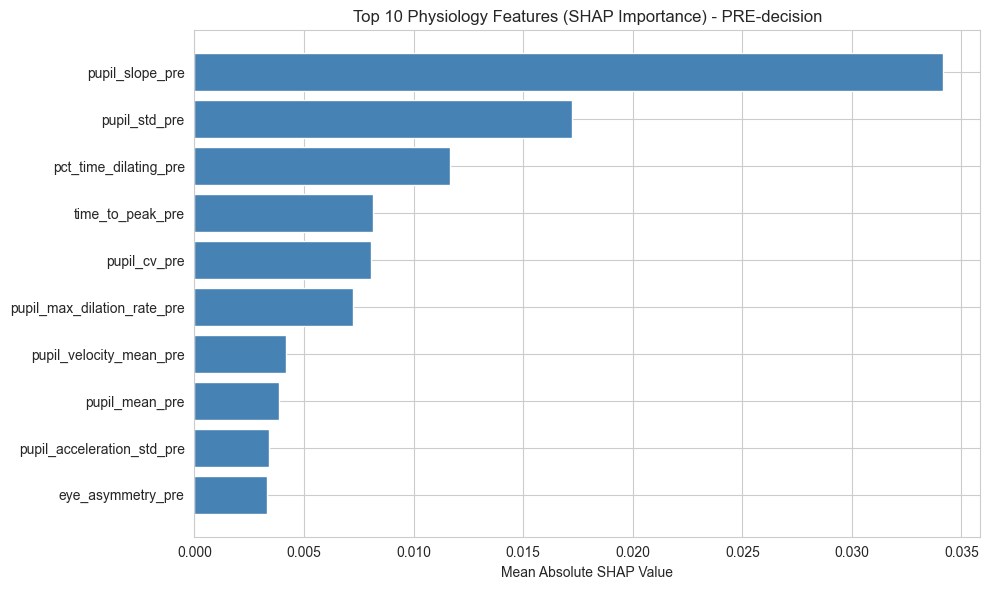

In [7]:
# Visualization: Bar plot of top 10 features
fig, ax = plt.subplots(figsize=(10, 6))
top_10_phys = importance_phys.head(10)
ax.barh(range(len(top_10_phys)), top_10_phys['mean_abs_shap'], color='steelblue')
ax.set_yticks(range(len(top_10_phys)))
ax.set_yticklabels(top_10_phys['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title('Top 10 Physiology Features (SHAP Importance) - PRE-decision')
plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_physiology_top10_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Gaze Features

In [30]:
shap_values_gaze, importance_gaze, X_test_gaze = train_and_get_shap(
    X_gaze, y, subjects, available_gaze, "Gaze"
)

print("\nTop 10 Gaze Features:")
print(importance_gaze.to_string(index=False))


Computing SHAP values for Gaze
Input X shape: (9365, 20)
Number of feature names: 20
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

  SHAP array shape: (9365, 20)
  Expected: (9365, 20)
  Mean absolute SHAP shape: (20,)
  Mean absolute SHAP length: 20
  Feature names length: 20

✓ SHAP computation complete for Gaze
  Total samples: 9365
  Total features: 20

Top 10 Gaze Features:
               feature  mean_abs_shap
     gaze_dispersion_x       0.035837
           gaze_x_mean       0.034873
            gaze_x_std       0.034342
          screen_x_std       0.028359
      gaze_path_length       0.016330
          screen_y_std       0.011380
         screen_x_mean       0.010671
 gaze_acceleration_std       0.009245
           gaze_y_mean       0.008914
         screen_y_mean       0.005796
gaze_acceleration_mean       0.005288
     gaze_dispersion_y       0.005248
            gaze_y_std       0.003588
    gaze_velocity_mean       0.003

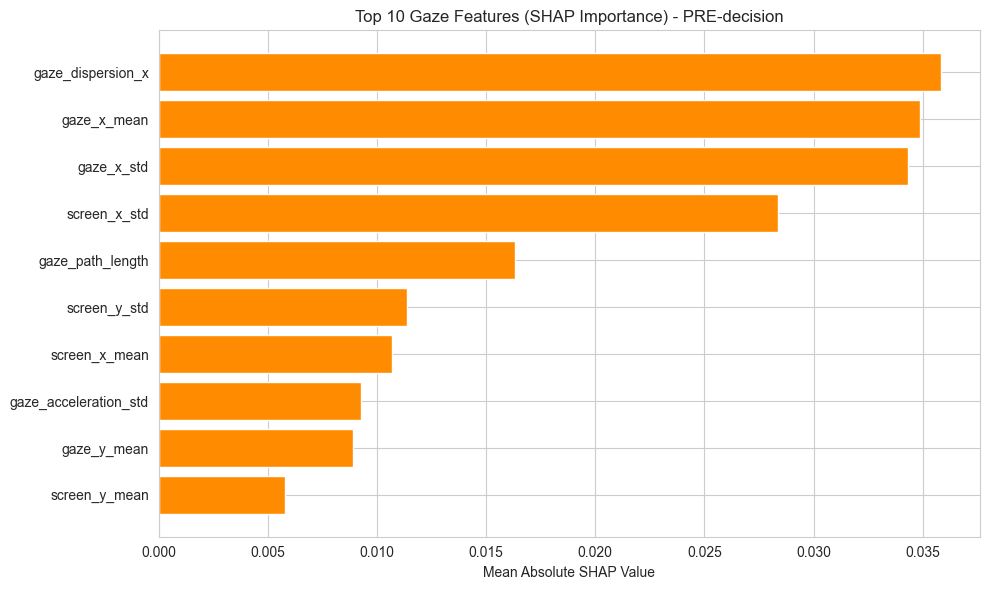

In [9]:
# Visualization: Bar plot of top 10 gaze features
fig, ax = plt.subplots(figsize=(10, 6))
top_10_gaze = importance_gaze.head(10)
ax.barh(range(len(top_10_gaze)), top_10_gaze['mean_abs_shap'], color='darkorange')
ax.set_yticks(range(len(top_10_gaze)))
ax.set_yticklabels(top_10_gaze['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title('Top 10 Gaze Features (SHAP Importance) - PRE-decision')
plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_gaze_top10_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Behavior Features

In [10]:
shap_values_behavior, importance_behavior, X_test_behavior = train_and_get_shap(
    X_behavior, y, subjects, available_behavior, "Behavior"
)

print("\nAll Behavior Features:")
print(importance_behavior.to_string(index=False))


Computing SHAP values for Behavior
Input X shape: (9365, 5)
Number of feature names: 5
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

  SHAP array shape: (9365, 5)
  Expected: (9365, 5)
  Mean absolute SHAP shape: (5,)
  Mean absolute SHAP length: 5
  Feature names length: 5

✓ SHAP computation complete for Behavior
  Total samples: 9365
  Total features: 5

All Behavior Features:
         feature  mean_abs_shap
       ambiguity       0.128655
 invest_variance       0.020408
    risk_premium       0.018660
   ev_difference       0.016582
condition_social       0.002861


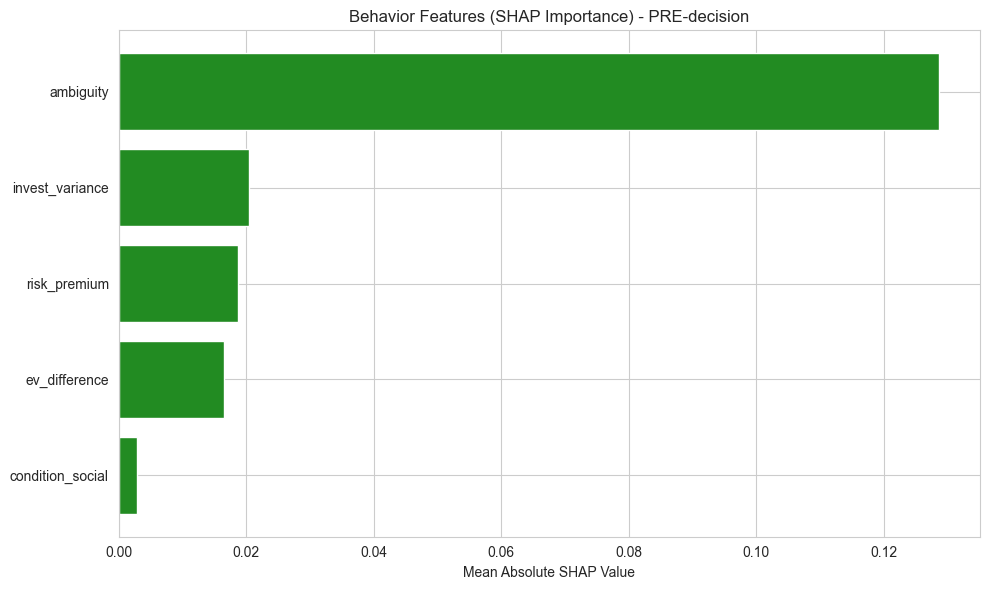

In [11]:
# Visualization: Bar plot of behavior features
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(importance_behavior)), importance_behavior['mean_abs_shap'], color='forestgreen')
ax.set_yticks(range(len(importance_behavior)))
ax.set_yticklabels(importance_behavior['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title(f'Behavior Features (SHAP Importance) - {TIMEFRAME}-decision')
plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_behavior_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. EEG Features (Band Power × Region)

In [12]:
shap_values_eeg, importance_eeg, X_test_eeg = train_and_get_shap(
    X_eeg, y, subjects, available_eeg, "EEG (band × region)"
)

print("\nAll EEG Features:")
print(importance_eeg.to_string(index=False))


Computing SHAP values for EEG (band × region)
Input X shape: (9365, 16)
Number of feature names: 16
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

  SHAP array shape: (9365, 16)
  Expected: (9365, 16)
  Mean absolute SHAP shape: (16,)
  Mean absolute SHAP length: 16
  Feature names length: 16

✓ SHAP computation complete for EEG (band × region)
  Total samples: 9365
  Total features: 16

All EEG Features:
            feature  mean_abs_shap
   eeg_Beta_Frontal       0.017373
  eeg_Beta_Parietal       0.009746
  eeg_Theta_Frontal       0.009692
   eeg_Beta_Central       0.009104
 eeg_Beta_Occipital       0.007805
  eeg_Alpha_Frontal       0.007169
  eeg_Delta_Frontal       0.006725
 eeg_Theta_Parietal       0.004893
  eeg_Delta_Central       0.004492
  eeg_Theta_Central       0.004114
  eeg_Alpha_Central       0.003899
 eeg_Alpha_Parietal       0.003490
 eeg_Delta_Parietal       0.002943
eeg_Alpha_Occipital       0.002584
eeg_Delta_Occip

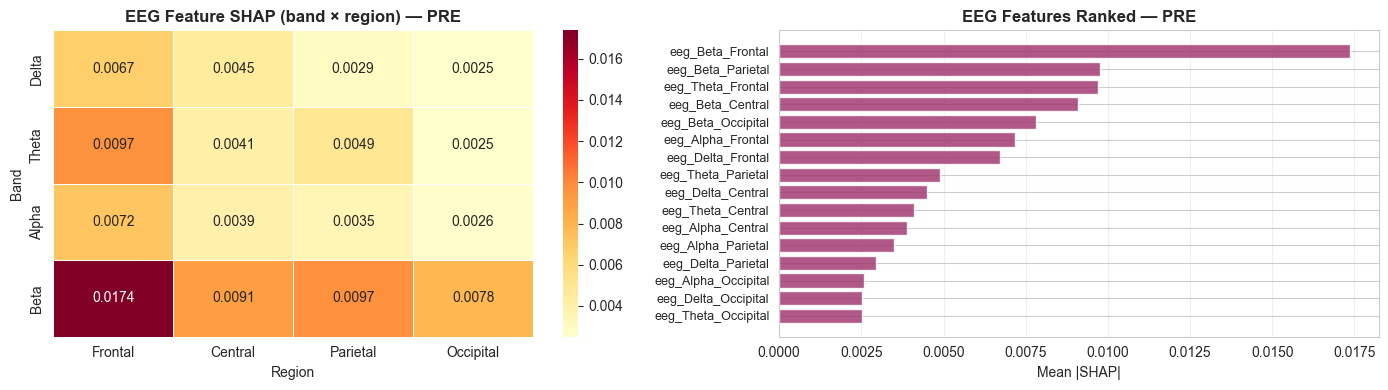

In [13]:
# Visualization: EEG features as heatmap (band × region)
bands   = ['Delta', 'Theta', 'Alpha', 'Beta']
regions = ['Frontal', 'Central', 'Parietal', 'Occipital']

heat = pd.DataFrame(index=bands, columns=regions, dtype=float)
for feat, val in zip(importance_eeg['feature'], importance_eeg['mean_abs_shap']):
    # feat looks like eeg_Delta_Frontal
    parts = feat.split('_')   # ['eeg', 'Delta', 'Frontal']
    band, region = parts[1], parts[2]
    heat.loc[band, region] = val

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(heat.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'EEG Feature SHAP (band × region) — {TIMEFRAME}', fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Band')

# Bar chart
axes[1].barh(range(len(importance_eeg)), importance_eeg['mean_abs_shap'], color='#A23B72', alpha=0.85)
axes[1].set_yticks(range(len(importance_eeg)))
axes[1].set_yticklabels(importance_eeg['feature'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean |SHAP|')
axes[1].set_title(f'EEG Features Ranked — {TIMEFRAME}', fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_eeg_{TIMEFRAME}.png',
            dpi=300, bbox_inches='tight')
plt.show()

## 5. Combined (Physiology + Gaze) Features

In [14]:
shap_values_phys_gaze, importance_phys_gaze, X_test_phys_gaze = train_and_get_shap(
    X_phys_gaze, y, subjects, available_physiology + available_gaze, "Combined (Physiology + Gaze)"
)

print("\nTop 20 Physiology + Gaze Features:")
print(importance_phys_gaze.head(20).to_string(index=False))


Computing SHAP values for Combined (Physiology + Gaze)
Input X shape: (9365, 33)
Number of feature names: 33
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

  SHAP array shape: (9365, 33)
  Expected: (9365, 33)
  Mean absolute SHAP shape: (33,)
  Mean absolute SHAP length: 33
  Feature names length: 33

✓ SHAP computation complete for Combined (Physiology + Gaze)
  Total samples: 9365
  Total features: 33

Top 20 Physiology + Gaze Features:
               feature  mean_abs_shap
     gaze_dispersion_x       0.029846
           gaze_x_mean       0.029065
            gaze_x_std       0.028615
          screen_x_std       0.027742
      gaze_path_length       0.015034
       pupil_slope_pre       0.013637
          screen_y_std       0.008562
         screen_x_mean       0.008186
 gaze_acceleration_std       0.007675
         pupil_std_pre       0.007126
           gaze_y_mean       0.006850
 pct_time_dilating_pre       0.005073
     gaze_d

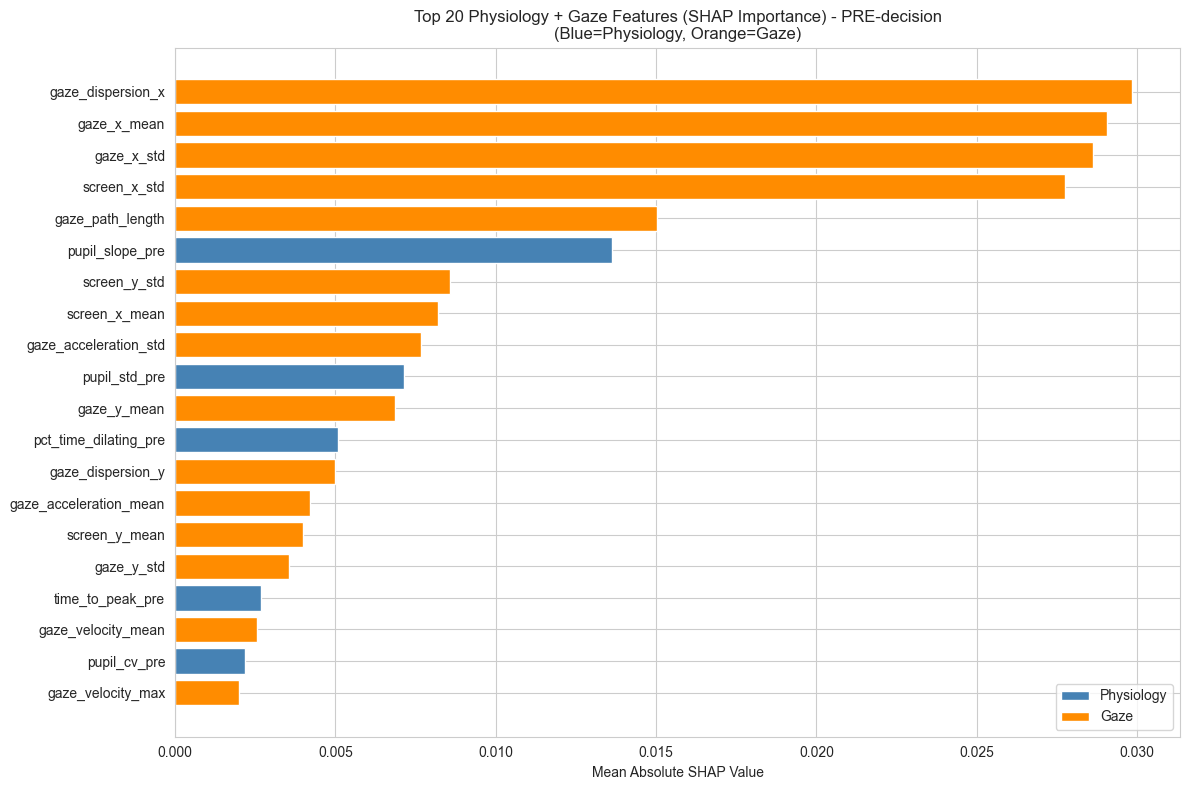

In [15]:
# Visualization: Bar plot of top 20 combined features
fig, ax = plt.subplots(figsize=(12, 8))
top_20_phys_gaze = importance_phys_gaze.head(20)
colors = ['steelblue' if f in available_physiology else 'darkorange' for f in top_20_phys_gaze['feature']]
ax.barh(range(len(top_20_phys_gaze)), top_20_phys_gaze['mean_abs_shap'], color=colors)
ax.set_yticks(range(len(top_20_phys_gaze)))
ax.set_yticklabels(top_20_phys_gaze['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title(f'Top 20 Physiology + Gaze Features (SHAP Importance) - {TIMEFRAME}-decision\n(Blue=Physiology, Orange=Gaze)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Physiology'),
    Patch(facecolor='darkorange', label='Gaze')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_phys_gaze_top20_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. All Features (Physiology + Gaze + Behavior)

In [16]:
shap_values_all, importance_all, X_test_all = train_and_get_shap(
    X_all, y, subjects, available_physiology + available_gaze + available_behavior, "All Features"
)

print("\nTop 25 Features (All Modalities):")
print(importance_all.head(25).to_string(index=False))


Computing SHAP values for All Features
Input X shape: (9365, 38)
Number of feature names: 38
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

  SHAP array shape: (9365, 38)
  Expected: (9365, 38)
  Mean absolute SHAP shape: (38,)
  Mean absolute SHAP length: 38
  Feature names length: 38

✓ SHAP computation complete for All Features
  Total samples: 9365
  Total features: 38

Top 25 Features (All Modalities):
               feature  mean_abs_shap
             ambiguity       0.062812
            gaze_x_std       0.029676
     gaze_dispersion_x       0.025649
           gaze_x_mean       0.024608
          screen_x_std       0.021620
      gaze_path_length       0.013174
       pupil_slope_pre       0.010713
       invest_variance       0.009528
         ev_difference       0.009440
          risk_premium       0.008651
         pupil_std_pre       0.008233
         screen_x_mean       0.006285
 gaze_acceleration_std       0.006169
      

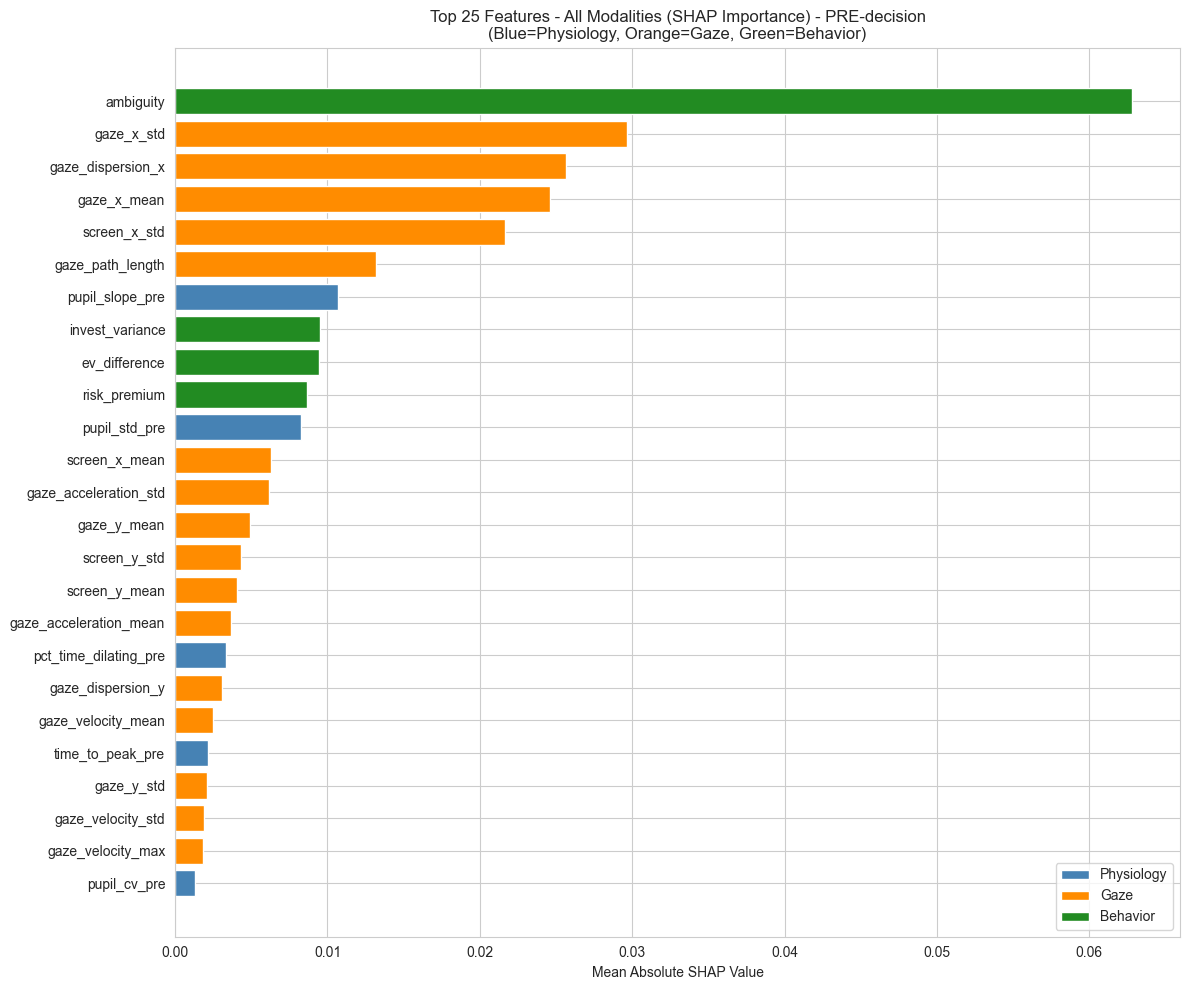

In [17]:
# Visualization: Bar plot of top 25 all features with color coding
fig, ax = plt.subplots(figsize=(12, 10))
top_25_all = importance_all.head(25)

# Color code by modality
def get_color(feature):
    if feature in available_physiology:
        return 'steelblue'
    elif feature in available_gaze:
        return 'darkorange'
    else:
        return 'forestgreen'

colors = [get_color(f) for f in top_25_all['feature']]
ax.barh(range(len(top_25_all)), top_25_all['mean_abs_shap'], color=colors)
ax.set_yticks(range(len(top_25_all)))
ax.set_yticklabels(top_25_all['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title(f'Top 25 Features - All Modalities (SHAP Importance) - {TIMEFRAME}-decision\n(Blue=Physiology, Orange=Gaze, Green=Behavior)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Physiology'),
    Patch(facecolor='darkorange', label='Gaze'),
    Patch(facecolor='forestgreen', label='Behavior')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_all_top25_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. SHAP Summary Plots

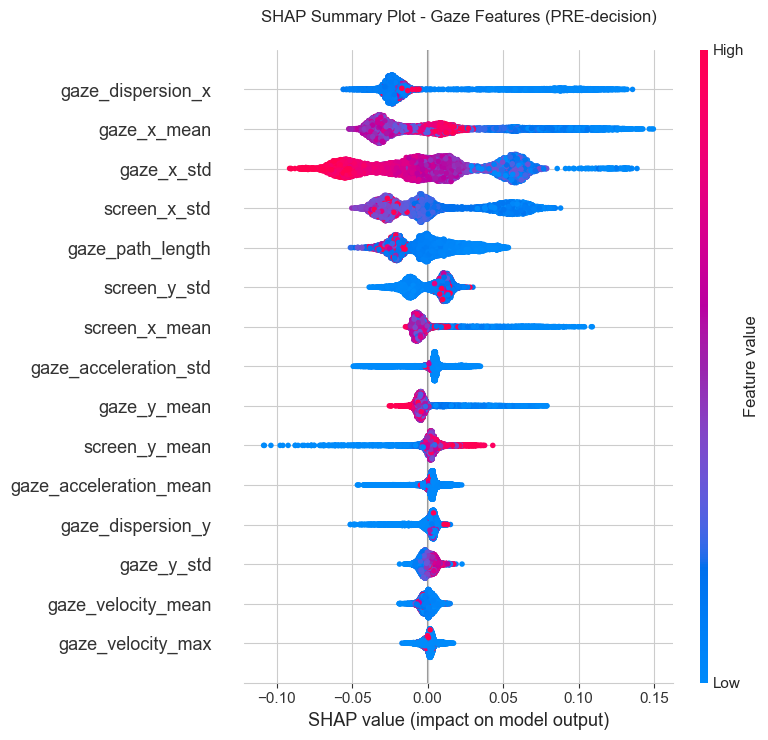

In [18]:
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_gaze, 
    X_test_gaze, 
    feature_names=available_gaze,
    max_display=15,
    show=False
)
plt.title(f'SHAP Summary Plot - Gaze Features ({TIMEFRAME}-decision)', pad=20)
plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_summary_gaze_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

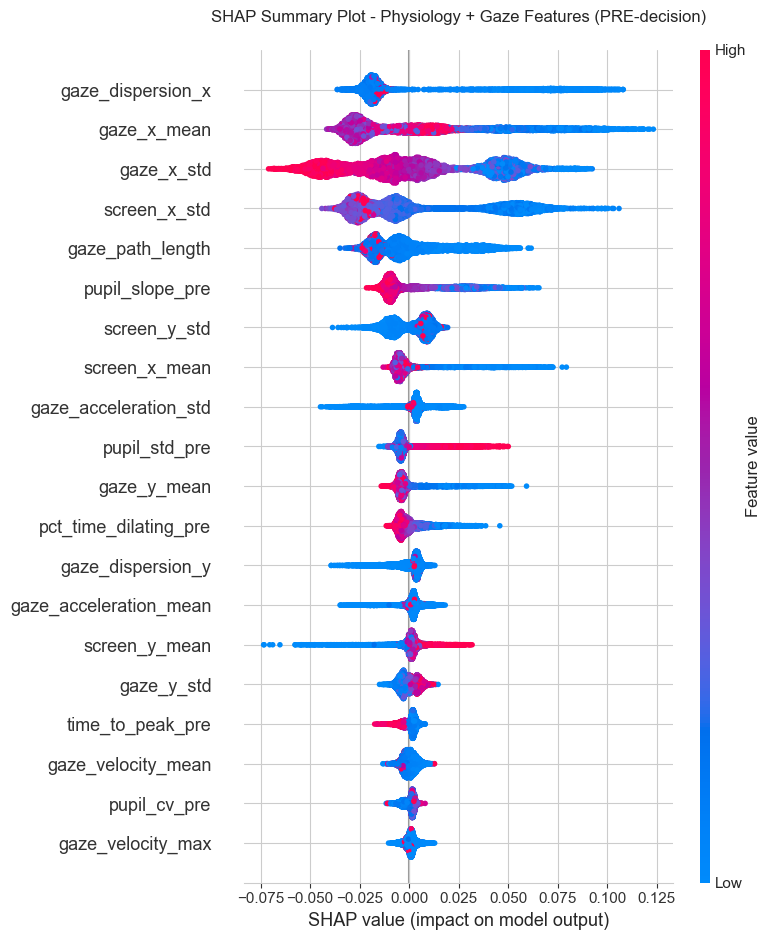

In [19]:
# SHAP summary plot for physiology + gaze features (top 20)
fig = plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values_phys_gaze, 
    X_test_phys_gaze, 
    feature_names=available_physiology + available_gaze,
    max_display=20,
    show=False
)
plt.title(f'SHAP Summary Plot - Physiology + Gaze Features ({TIMEFRAME}-decision)', pad=20)
plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_summary_phys_gaze_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

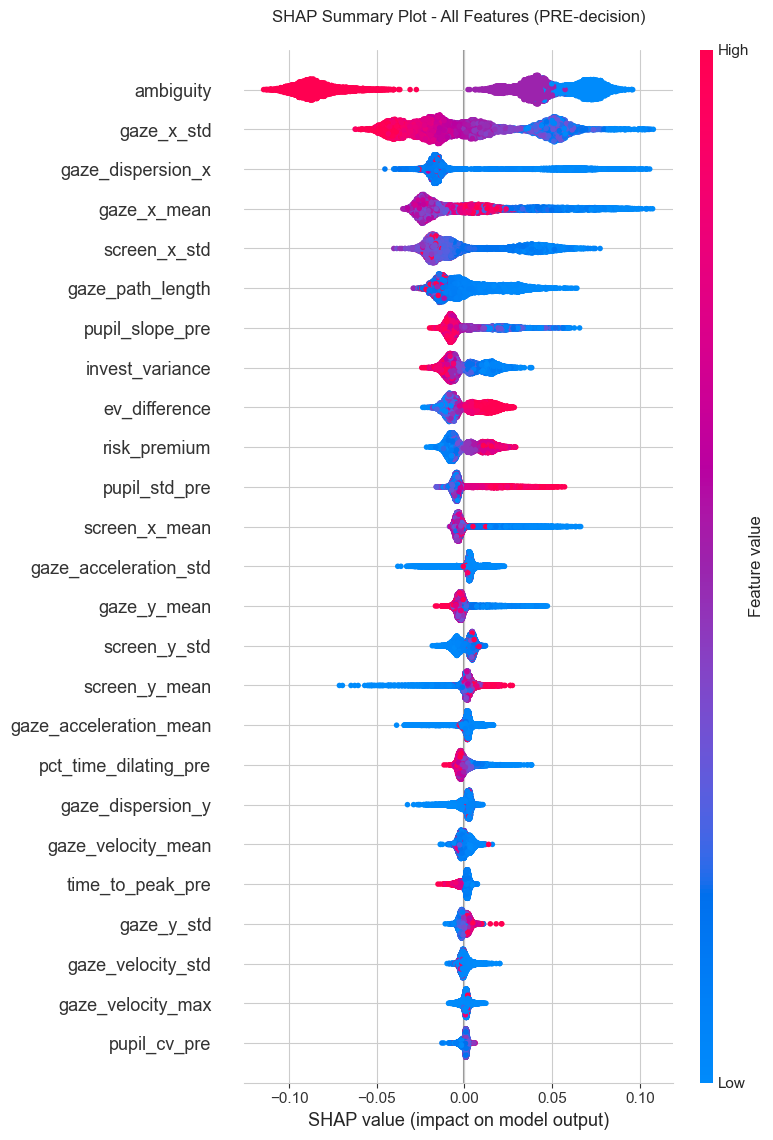

In [20]:
# SHAP summary plot for all features (top 25)
fig = plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values_all, 
    X_test_all, 
    feature_names=available_physiology + available_gaze + available_behavior,
    max_display=25,
    show=False
)
plt.title(f'SHAP Summary Plot - All Features ({TIMEFRAME}-decision)', pad=20)
plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/shap_summary_all_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Save feature importance tables
output_dir = Path(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}')
output_dir.mkdir(parents=True, exist_ok=True)

importance_phys.to_csv(output_dir / f'shap_importance_physiology_{TIMEFRAME}.csv', index=False)
importance_gaze.to_csv(output_dir / f'shap_importance_gaze_{TIMEFRAME}.csv', index=False)
importance_behavior.to_csv(output_dir / f'shap_importance_behavior_{TIMEFRAME}.csv', index=False)
importance_eeg.to_csv(output_dir / f'shap_importance_eeg_{TIMEFRAME}.csv', index=False)
importance_phys_gaze.to_csv(output_dir / f'shap_importance_phys_gaze_{TIMEFRAME}.csv', index=False)
importance_all.to_csv(output_dir / f'shap_importance_all_{TIMEFRAME}.csv', index=False)

print("✓ Feature importance tables saved:")
for name in ['physiology', 'gaze', 'behavior', 'eeg', 'phys_gaze', 'all']:
    print(f"  - shap_importance_{name}_{TIMEFRAME}.csv")

✓ Feature importance tables saved:
  - shap_importance_physiology_PRE.csv
  - shap_importance_gaze_PRE.csv
  - shap_importance_behavior_PRE.csv
  - shap_importance_eeg_PRE.csv
  - shap_importance_phys_gaze_PRE.csv
  - shap_importance_all_PRE.csv


## Summary

### Key Findings:

**Top 10 Features Overall (All Modalities Model):**

In [22]:
# Print formatted summary
print("\n" + "="*70)
print(f"TOP 10 FEATURES DRIVING {TIMEFRAME}-DECISION PREDICTIONS")
print(f"(All Modalities: Physiology + Gaze + Behavior)")
print("="*70)

top_10_overall = importance_all.head(10).copy()

def get_modality(feature):
    if feature in available_physiology:
        return 'Physiology'
    elif feature in available_gaze:
        return 'Gaze'
    else:
        return 'Behavior'

top_10_overall['modality'] = top_10_overall['feature'].apply(get_modality)
top_10_overall['rank'] = range(1, 11)

print(top_10_overall[['rank', 'feature', 'modality', 'mean_abs_shap']].to_string(index=False))

# Count by modality
modality_counts = top_10_overall['modality'].value_counts()
print(f"\nModality breakdown in top 10:")
print(f"  Physiology: {modality_counts.get('Physiology', 0)} features")
print(f"  Gaze: {modality_counts.get('Gaze', 0)} features")
print(f"  Behavior: {modality_counts.get('Behavior', 0)} features")


TOP 10 FEATURES DRIVING PRE-DECISION PREDICTIONS
(All Modalities: Physiology + Gaze + Behavior)
 rank           feature   modality  mean_abs_shap
    1         ambiguity   Behavior       0.062812
    2        gaze_x_std       Gaze       0.029676
    3 gaze_dispersion_x       Gaze       0.025649
    4       gaze_x_mean       Gaze       0.024608
    5      screen_x_std       Gaze       0.021620
    6  gaze_path_length       Gaze       0.013174
    7   pupil_slope_pre Physiology       0.010713
    8   invest_variance   Behavior       0.009528
    9     ev_difference   Behavior       0.009440
   10      risk_premium   Behavior       0.008651

Modality breakdown in top 10:
  Physiology: 1 features
  Gaze: 5 features
  Behavior: 4 features


## Stratified SHAP Analysis by Ambiguity Level

For each modality, compute per-feature SHAP importance separately for Low / Medium / High ambiguity trials. This tells us which features matter most under different levels of decision difficulty.

In [23]:
def train_and_get_shap_subset(X, y, subjects, feature_names, model_name="Model"):
    """
    Same as train_and_get_shap but works on an arbitrary (filtered) subset.
    Subjects with < 2 trials in the subset are dropped so LOSO still makes sense.
    Returns (shap_values_array, feature_importance_df, X_reordered).
    """
    # Drop subjects with too few trials for LOSO
    min_trials = 2
    counts = pd.Series(subjects).value_counts()
    keep_subj = counts[counts >= min_trials].index
    mask = np.isin(subjects, keep_subj)
    X, y, subjects = X[mask], y[mask], subjects[mask]

    if len(np.unique(subjects)) < 2:
        print(f"  [SKIP] {model_name}: not enough subjects after filtering")
        return None, None, None

    logo = LeaveOneGroupOut()
    all_shap_values = []
    all_test_indices = []

    rf = RandomForestClassifier(
        n_estimators=100, max_depth=5,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    )

    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        rf.fit(X_train, y_train)
        explainer = shap.TreeExplainer(rf)
        sv = explainer.shap_values(X_test)
        if isinstance(sv, list):
            sv = sv[1]
        if len(sv.shape) == 3:
            sv = sv[:, :, 1]
        if len(sv.shape) == 1:
            sv = sv.reshape(1, -1)
        all_shap_values.append(sv)
        all_test_indices.extend(test_idx)

    shap_arr = np.vstack(all_shap_values)
    mean_abs = np.abs(shap_arr).mean(axis=0)

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    print(f"  {model_name}: {shap_arr.shape[0]} trials, {len(np.unique(subjects))} subjects")
    return shap_arr, importance_df, X[all_test_indices]


# Ensure ambiguity_group column exists (created from the 'ambiguity' quantile cut)
if 'ambiguity_group' not in data.columns:
    terciles = data['ambiguity'].quantile([1/3, 2/3])
    data['ambiguity_group'] = pd.cut(
        data['ambiguity'],
        bins=[-np.inf, terciles.iloc[0], terciles.iloc[1], np.inf],
        labels=['Low', 'Medium', 'High']
    )

print("Ambiguity group counts:")
print(data['ambiguity_group'].value_counts().sort_index())

Ambiguity group counts:
ambiguity_group
Low       3143
Medium    3121
High      3101
Name: count, dtype: int64


In [24]:
# Run stratified SHAP for each modality x ambiguity level
AMB_LEVELS = ['Low', 'Medium', 'High']
MODALITIES_AMB = {
    'Physiology': (X_physiology, available_physiology),
    'Gaze':       (X_gaze,       available_gaze),
    'Behavior':   (X_behavior,   available_behavior),
    'EEG':        (X_eeg,        available_eeg),
}

shap_by_amb = {}   # {modality: {amb_level: importance_df}}

for mod_name, (X_mod, feat_names) in MODALITIES_AMB.items():
    shap_by_amb[mod_name] = {}
    print(f"\n{'='*60}")
    print(f"Modality: {mod_name}")
    print(f"{'='*60}")
    for amb in AMB_LEVELS:
        mask = (data['ambiguity_group'] == amb).values
        _, imp_df, _ = train_and_get_shap_subset(
            X_mod[mask], y[mask], subjects[mask],
            feat_names, model_name=f"{mod_name} | {amb} ambiguity"
        )
        if imp_df is not None:
            imp_df['ambiguity'] = amb
            shap_by_amb[mod_name][amb] = imp_df


Modality: Physiology
  Physiology | Low ambiguity: 3143 trials, 80 subjects
  Physiology | Medium ambiguity: 3121 trials, 80 subjects
  Physiology | High ambiguity: 3101 trials, 80 subjects

Modality: Gaze
  Gaze | Low ambiguity: 3143 trials, 80 subjects
  Gaze | Medium ambiguity: 3121 trials, 80 subjects
  Gaze | High ambiguity: 3101 trials, 80 subjects

Modality: Behavior
  Behavior | Low ambiguity: 3143 trials, 80 subjects
  Behavior | Medium ambiguity: 3121 trials, 80 subjects
  Behavior | High ambiguity: 3101 trials, 80 subjects

Modality: EEG
  EEG | Low ambiguity: 3143 trials, 80 subjects
  EEG | Medium ambiguity: 3121 trials, 80 subjects
  EEG | High ambiguity: 3101 trials, 80 subjects


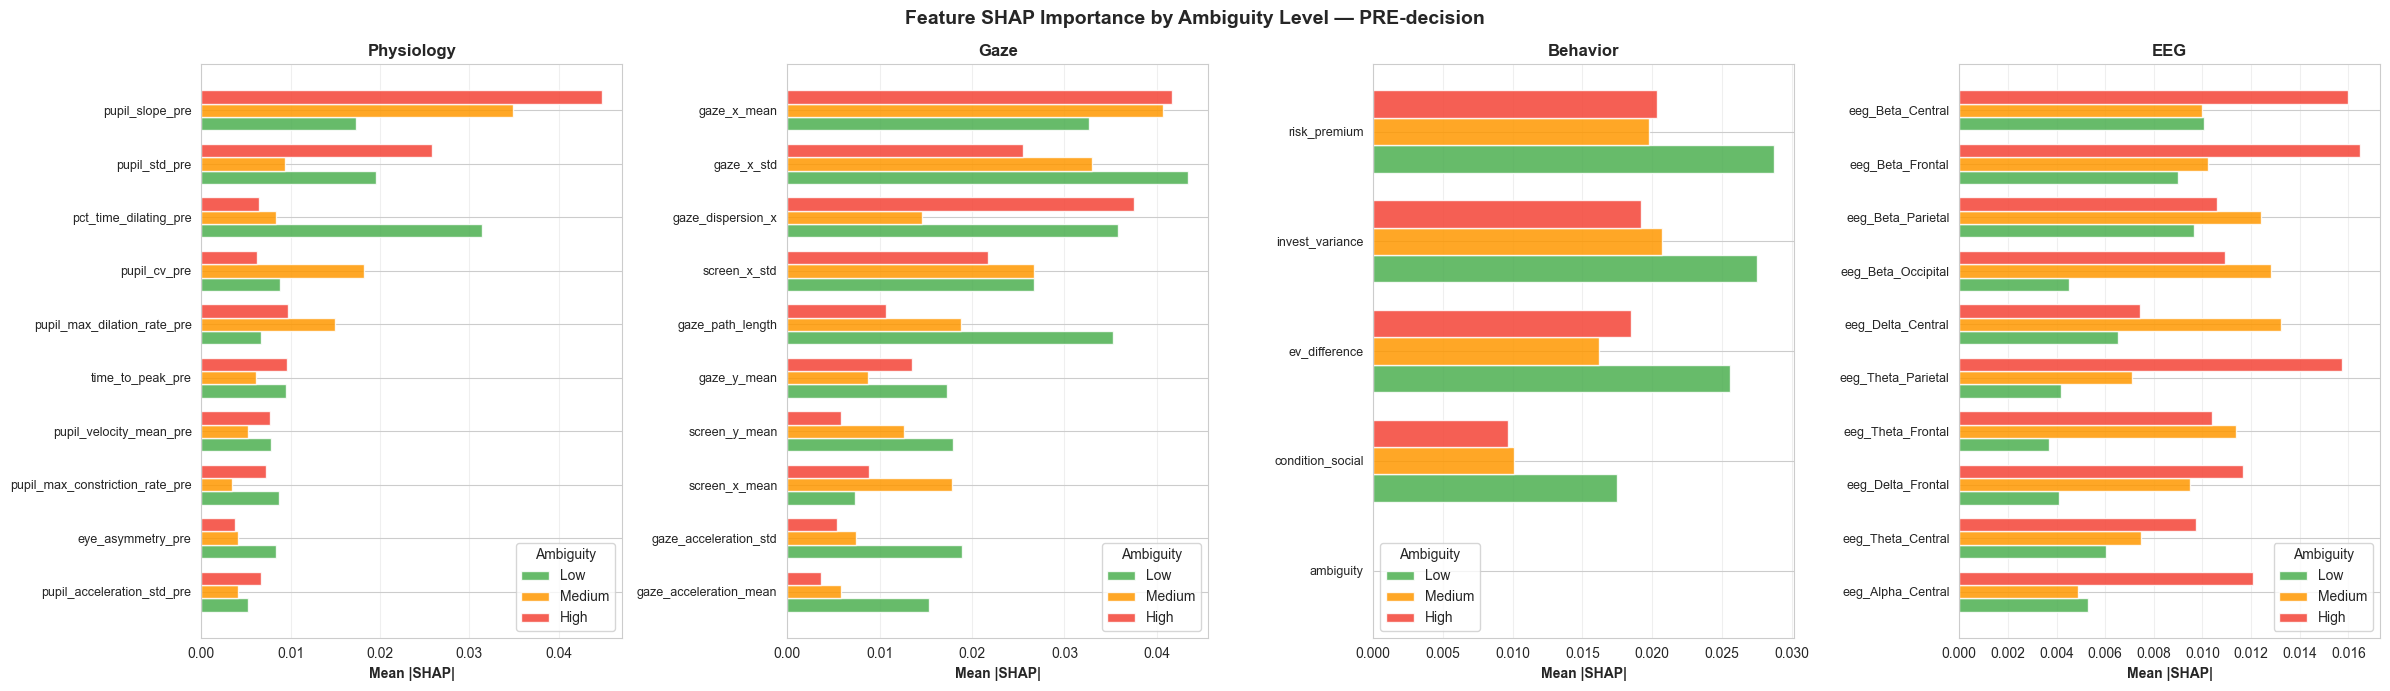

In [25]:
amb_colors = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
TOP_N = 10  # features to show per modality

n_mods = len(shap_by_amb)
fig, axes = plt.subplots(1, n_mods, figsize=(6 * n_mods, 7))
fig.suptitle(f'Feature SHAP Importance by Ambiguity Level — {TIMEFRAME}-decision',
             fontsize=14, fontweight='bold')

for ax, (mod_name, amb_dict) in zip(axes, shap_by_amb.items()):
    all_feats = []
    for df in amb_dict.values():
        all_feats.extend(df['feature'].head(TOP_N).tolist())
    mean_imp = {}
    for feat in set(all_feats):
        vals = [df.set_index('feature')['mean_abs_shap'].get(feat, 0)
                for df in amb_dict.values()]
        mean_imp[feat] = np.mean(vals)
    top_feats = sorted(mean_imp, key=mean_imp.get, reverse=True)[:TOP_N]
    top_feats = top_feats[::-1]

    y_pos = np.arange(len(top_feats))
    bar_h = 0.25
    offsets = {'Low': -bar_h, 'Medium': 0, 'High': bar_h}

    for amb in AMB_LEVELS:
        df = amb_dict.get(amb)
        if df is None:
            continue
        imp_map = df.set_index('feature')['mean_abs_shap'].to_dict()
        vals = [imp_map.get(f, 0) for f in top_feats]
        ax.barh(y_pos + offsets[amb], vals, height=bar_h,
                label=amb, color=amb_colors[amb], alpha=0.85)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats, fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontweight='bold')
    ax.set_title(mod_name, fontweight='bold')
    ax.legend(title='Ambiguity')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
out_fig = Path(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures')
out_fig.mkdir(parents=True, exist_ok=True)
plt.savefig(out_fig / f'shap_by_ambiguity_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Save stratified tables
out_csv = Path(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}')
for mod_name, amb_dict in shap_by_amb.items():
    rows = []
    for amb, df in amb_dict.items():
        rows.append(df.assign(ambiguity=amb))
    combined = pd.concat(rows, ignore_index=True)
    fname = f'shap_importance_{mod_name.lower()}_by_ambiguity_{TIMEFRAME}.csv'
    combined.to_csv(out_csv / fname, index=False)
    print(f"Saved: {fname}")

print("\nDone — stratified SHAP by ambiguity saved.")

Saved: shap_importance_physiology_by_ambiguity_PRE.csv
Saved: shap_importance_gaze_by_ambiguity_PRE.csv
Saved: shap_importance_behavior_by_ambiguity_PRE.csv
Saved: shap_importance_eeg_by_ambiguity_PRE.csv

Done — stratified SHAP by ambiguity saved.


## Stratified SHAP Analysis by Reaction Time Group

Same approach, but split into Fast vs Slow RT (median split on `reaction_time`). This shows whether different features drive predictions for quick vs deliberate decisions.

In [27]:
# Median split on reaction_time
rt_col = 'reaction_time' if 'reaction_time' in data.columns else 'decision_time'
median_rt = data[rt_col].median()
data['rt_group'] = np.where(data[rt_col] <= median_rt, 'Fast', 'Slow')

print(f"RT split on '{rt_col}' (median = {median_rt:.3f})")
print(data['rt_group'].value_counts())

RT_LEVELS = ['Fast', 'Slow']
MODALITIES_RT = MODALITIES_AMB  # same 4 modalities

shap_by_rt = {}

for mod_name, (X_mod, feat_names) in MODALITIES_RT.items():
    shap_by_rt[mod_name] = {}
    print(f"\n{'='*60}")
    print(f"Modality: {mod_name}")
    print(f"{'='*60}")
    for rt in RT_LEVELS:
        mask = (data['rt_group'] == rt).values
        _, imp_df, _ = train_and_get_shap_subset(
            X_mod[mask], y[mask], subjects[mask],
            feat_names, model_name=f"{mod_name} | {rt} RT"
        )
        if imp_df is not None:
            imp_df['rt_group'] = rt
            shap_by_rt[mod_name][rt] = imp_df

RT split on 'decision_time' (median = 2.177)
rt_group
Fast    4683
Slow    4682
Name: count, dtype: int64

Modality: Physiology
  Physiology | Fast RT: 4682 trials, 79 subjects
  Physiology | Slow RT: 4682 trials, 80 subjects

Modality: Gaze
  Gaze | Fast RT: 4682 trials, 79 subjects
  Gaze | Slow RT: 4682 trials, 80 subjects

Modality: Behavior
  Behavior | Fast RT: 4682 trials, 79 subjects
  Behavior | Slow RT: 4682 trials, 80 subjects

Modality: EEG
  EEG | Fast RT: 4682 trials, 79 subjects
  EEG | Slow RT: 4682 trials, 80 subjects


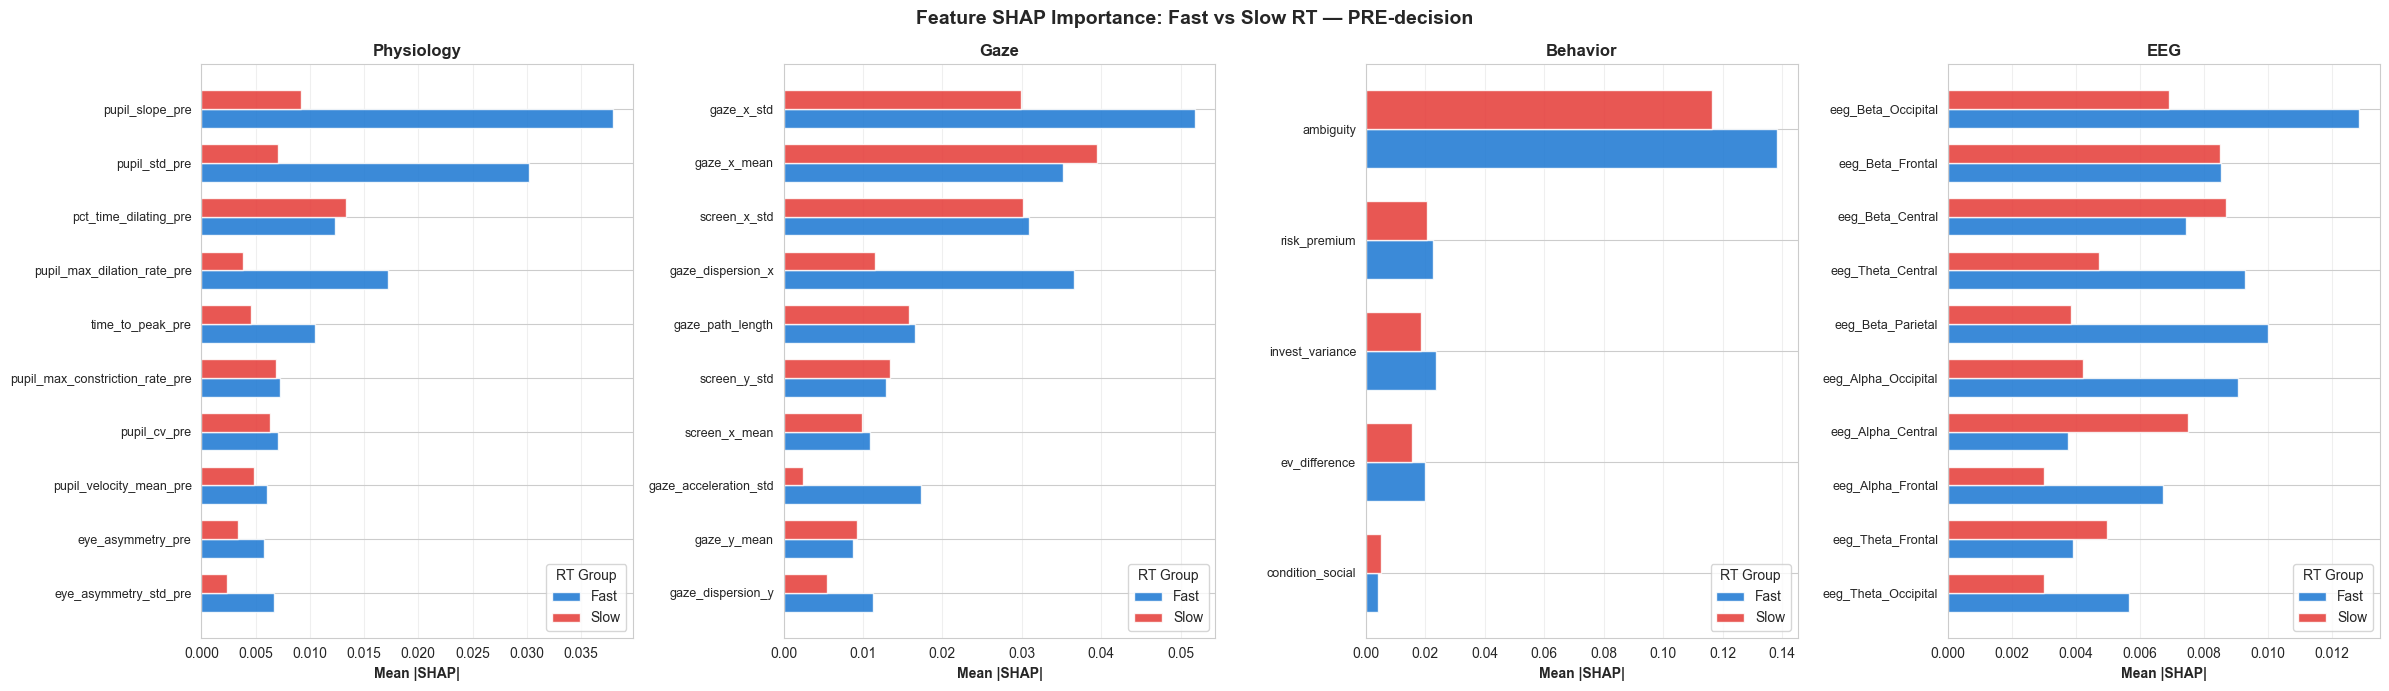

In [28]:
rt_colors = {'Fast': '#1976D2', 'Slow': '#E53935'}
TOP_N_RT = 10

n_mods = len(shap_by_rt)
fig, axes = plt.subplots(1, n_mods, figsize=(6 * n_mods, 7))
fig.suptitle(f'Feature SHAP Importance: Fast vs Slow RT — {TIMEFRAME}-decision',
             fontsize=14, fontweight='bold')

for ax, (mod_name, rt_dict) in zip(axes, shap_by_rt.items()):
    all_feats = []
    for df in rt_dict.values():
        all_feats.extend(df['feature'].head(TOP_N_RT).tolist())
    mean_imp = {}
    for feat in set(all_feats):
        vals = [df.set_index('feature')['mean_abs_shap'].get(feat, 0)
                for df in rt_dict.values()]
        mean_imp[feat] = np.mean(vals)
    top_feats = sorted(mean_imp, key=mean_imp.get, reverse=True)[:TOP_N_RT]
    top_feats = top_feats[::-1]

    y_pos = np.arange(len(top_feats))
    bar_h = 0.35
    offsets = {'Fast': -bar_h / 2, 'Slow': bar_h / 2}

    for rt in RT_LEVELS:
        df = rt_dict.get(rt)
        if df is None:
            continue
        imp_map = df.set_index('feature')['mean_abs_shap'].to_dict()
        vals = [imp_map.get(f, 0) for f in top_feats]
        ax.barh(y_pos + offsets[rt], vals, height=bar_h,
                label=rt, color=rt_colors[rt], alpha=0.85)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats, fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontweight='bold')
    ax.set_title(mod_name, fontweight='bold')
    ax.legend(title='RT Group')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(out_fig / f'shap_by_rt_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# Save RT-stratified tables
for mod_name, rt_dict in shap_by_rt.items():
    rows = [df.assign(rt_group=rt) for rt, df in rt_dict.items()]
    combined = pd.concat(rows, ignore_index=True)
    fname = f'shap_importance_{mod_name.lower()}_by_rt_{TIMEFRAME}.csv'
    combined.to_csv(out_csv / fname, index=False)
    print(f"Saved: {fname}")

print("\nDone — stratified SHAP by RT saved.")

Saved: shap_importance_physiology_by_rt_PRE.csv
Saved: shap_importance_gaze_by_rt_PRE.csv
Saved: shap_importance_behavior_by_rt_PRE.csv
Saved: shap_importance_eeg_by_rt_PRE.csv

Done — stratified SHAP by RT saved.
